---
title: "Wikidata Item Profile"
format:
  html:
    toc: false
    code-fold: true
    code-summary: "Show code"
execute:
  echo: false
  warning: false
  error: false
jupyter: python3
---

# Wikidata Item Profile

This notebook-backed page queries Wikidata with SPARQL and renders a styled HTML profile.

To profile another item, change the `item_id` value in Cell 3 and re-render the site.

In [1]:
from IPython.display import HTML, Markdown
from wikidata_profile import (
    build_statement_query,
    fetch_sparql_bindings,
    properties_from_bindings,
    render_profile_html,
)

In [2]:
item_id = "Q138572984"
item_id = item_id.strip().upper()

if not item_id.startswith("Q") or not item_id[1:].isdigit():
    raise ValueError("item_id must be a Wikidata Q-id like Q42 or Q138547468")

query = build_statement_query(item_id)
Markdown(
    f"## SPARQL Query Used for {item_id}\n```sparql\n" + query + "\n```"
 )

## SPARQL Query Used for Q138572984
```sparql
SELECT ?property ?propertyLabel ?value ?valueLabel WHERE {
  BIND(wd:Q138572984 AS ?item)
  ?item ?p ?statement .
  ?property wikibase:claim ?p .
  ?statement ?ps ?value .
  ?property wikibase:statementProperty ?ps .

  SERVICE wikibase:label { bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en". }
}
ORDER BY ?propertyLabel
```

In [3]:
bindings = fetch_sparql_bindings(query)
properties = properties_from_bindings(bindings)
len(bindings)

12

In [4]:
HTML(render_profile_html(item_id, properties))

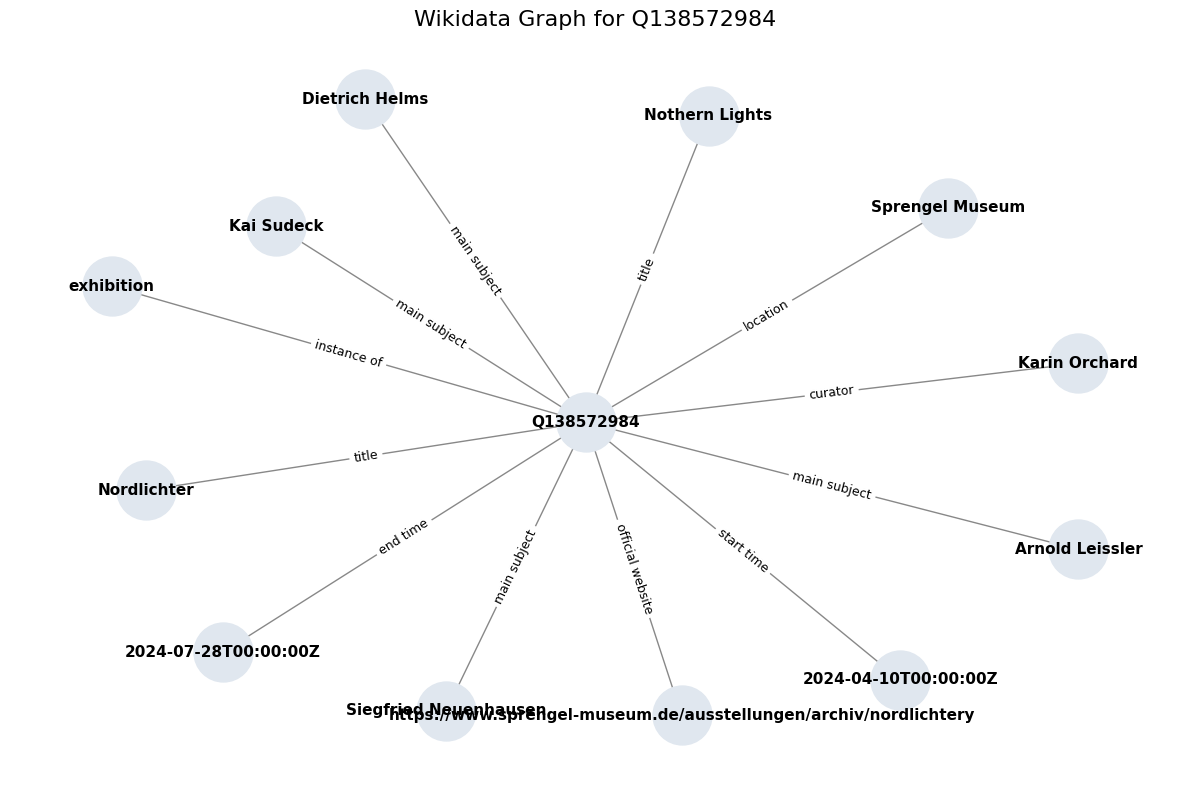

In [ ]:
# Visualize the Wikidata item as a graph
# Renders as inline SVG so it is preserved in the Quarto website output
import math
from html import escape

import networkx as nx
from IPython.display import HTML, Markdown

# Build a directed graph from the bindings
G = nx.DiGraph()

for b in bindings:
    subj = b.get('itemLabel', {}).get('value', item_id)
    prop = b.get('propertyLabel', {}).get('value', b.get('property', {}).get('value', ''))
    obj = b.get('valueLabel', {}).get('value', b.get('value', {}).get('value', ''))
    if obj and prop:
        G.add_edge(subj, obj, label=prop)

if G.number_of_edges() == 0:
    Markdown('No graph data available for this item.')
else:
    pos = nx.spring_layout(G, k=0.7, seed=42)
    width, height = 900, 600
    margin = 60

    xs = [x for _, x in pos.items()]
    ys = [y for _, y in pos.items()]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    def to_svg_xy(point):
        x, y = point
        if max_x - min_x < 1e-9:
            sx = width / 2
        else:
            sx = margin + (x - min_x) / (max_x - min_x) * (width - 2 * margin)
        if max_y - min_y < 1e-9:
            sy = height / 2
        else:
            sy = height - margin - (y - min_y) / (max_y - min_y) * (height - 2 * margin)
        return sx, sy

    parts = []
    parts.append('<svg xmlns="http://www.w3.org/2000/svg" width="100%" viewBox="0 0 900 600" style="max-width: 100%; height: auto;">')
    parts.append('<defs><marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth"><path d="M0,0 L0,6 L9,3 z" fill="#64748b" /></marker></defs>')

    for source, target, data in G.edges(data=True):
        x1, y1 = to_svg_xy(pos[source])
        x2, y2 = to_svg_xy(pos[target])
        dx, dy = x2 - x1, y2 - y1
        length = math.hypot(dx, dy) or 1
        nx1, ny1 = dx / length * 14, dy / length * 14
        label_x = (x1 + x2) / 2
        label_y = (y1 + y2) / 2
        parts.append(
            f'<line x1="{x1:.1f}" y1="{y1:.1f}" x2="{x2 - nx1:.1f}" y2="{y2 - ny1:.1f}" stroke="#64748b" stroke-width="2" marker-end="url(#arrow)" />'
        )
        parts.append(
            f'<text x="{label_x:.1f}" y="{label_y:.1f}" fill="#334155" font-size="12" text-anchor="middle" dominant-baseline="middle">{escape(data.get("label", ""))}</text>'
        )

    for node, (x, y) in pos.items():
        sx, sy = to_svg_xy((x, y))
        parts.append(f'<circle cx="{sx:.1f}" cy="{sy:.1f}" r="20" fill="#e0e7ef" stroke="#475569" stroke-width="1.5" />')
        parts.append(f'<text x="{sx:.1f}" y="{sy:.1f}" fill="#0f172a" font-size="12" text-anchor="middle" dominant-baseline="middle">{escape(node)}</text>')

    parts.append('</svg>')
    HTML(''.join(parts))